# Load in NLR DB data for swift creek

In [50]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
def remove_header(df):
    """Deletes first row of df and sets column names to new first row
    """
    df = df[1:]
    df.columns = df.iloc[0]
    df = df[1:]
    return df

In [33]:
def drop_nan_columns(df):
    """Drops columns with all NaN values
    """
    df = df.dropna(axis=1, how='all')
    
    return df

In [34]:
def floatify_columns(df):
    # Convert all columns to float
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def rename_columns(df):
    map_name = {"Temperature": "Air Temperature"}
    # Map columns to new names
    df = df.rename(columns=map_name)
    return df

In [58]:
def make_datetime(df):
    # Combine "Year, Month, Day, Hour, Minute" into a single datetime column
    df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])
    return df

In [ ]:
def smooth_wind_direction(df):
    """Wind direction ranges from 0 to 360 degrees. This function converts the wind direction to a sine value, which is useful for machine learning models.
    """
    df['Smooth Wind Direction'] = np.sin(2 * np.pi * df['Wind Direction'] / 360) #TODO is this correct?

    return df

In [89]:
def load_one(file_path):
    df = pd.read_csv(file_path)
    df = remove_header(df)
    df = drop_nan_columns(df)
    df = floatify_columns(df)
    df = rename_columns(df)
    df = make_datetime(df)
    df = smooth_wind_direction(df)
    return df

In [90]:
def load_data(folder_path):
    dataframes = []
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = load_one(file_path)
            dataframes.append(df)
    # Concatenate all dataframes into one
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

In [1]:
df = load_data('NLRDB')

NameError: name 'load_data' is not defined

In [92]:
df

1,Year,Month,Day,Hour,Minute,Air Temperature,Alpha,Aerosol Optical Depth,Asymmetry,Clearsky DHI,...,Relative Humidity,Solar Zenith Angle,SSA,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed,DateTime,Smooth Wind Direction
0,2018,1,1,0,0,0.5,1.45,0.117,0.63,0,...,71.11,170.93,0.95,0.14,1030,1.0,3,3.4,2018-01-01 00:00:00,0.052336
1,2018,1,1,1,0,0.0,1.45,0.105,0.63,0,...,68.94,169.46,0.95,0.14,1030,1.0,7,3.4,2018-01-01 01:00:00,0.121869
2,2018,1,1,2,0,-0.5,1.46,0.092,0.63,0,...,68.37,157.69,0.95,0.14,1031,1.0,8,3.2,2018-01-01 02:00:00,0.139173
3,2018,1,1,3,0,-0.9,1.46,0.079,0.63,0,...,67.62,144.83,0.94,0.14,1031,1.0,9,3.0,2018-01-01 03:00:00,0.156434
4,2018,1,1,4,0,-1.3,1.44,0.069,0.63,0,...,66.63,131.88,0.94,0.14,1031,1.0,9,3.0,2018-01-01 04:00:00,0.156434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70123,2025,12,31,19,0,10.7,1.35,0.023,0.63,0,...,84.74,108.46,0.88,0.15,1015,0.9,10,1.2,2025-12-31 19:00:00,0.173648
70124,2025,12,31,20,0,9.9,1.37,0.024,0.63,0,...,88.24,121.07,0.88,0.15,1016,0.8,14,1.2,2025-12-31 20:00:00,0.241922
70125,2025,12,31,21,0,9.4,1.39,0.025,0.63,0,...,89.64,133.93,0.88,0.15,1016,0.8,18,1.3,2025-12-31 21:00:00,0.309017
70126,2025,12,31,22,0,8.8,1.41,0.026,0.63,0,...,91.45,146.89,0.89,0.15,1017,0.8,21,1.4,2025-12-31 22:00:00,0.358368


# Feature analysis

- Convert Wind Direction to a sinusoidal value (currently 0 to 360)

In [93]:
df.describe()

1,Year,Month,Day,Hour,Minute,Air Temperature,Alpha,Aerosol Optical Depth,Asymmetry,Clearsky DHI,...,Relative Humidity,Solar Zenith Angle,SSA,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed,DateTime,Smooth Wind Direction
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.0,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,...,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128,70128.000000
mean,2021.500342,6.522930,15.729637,11.500000,0.0,21.305256,1.207004,0.147599,0.620931,52.897088,...,76.394229,89.723662,0.946350,0.156851,1012.018295,3.056751,161.997733,1.533629,2021-12-31 23:30:00,0.204975
min,2018.000000,1.000000,1.000000,0.000000,0.0,-10.600000,0.060000,0.011000,0.600000,0.000000,...,12.390000,8.410000,0.830000,0.100000,992.000000,0.200000,0.000000,0.000000,2018-01-01 00:00:00,-1.000000
25%,2020.000000,4.000000,8.000000,5.750000,0.0,15.300000,1.010000,0.078000,0.620000,0.000000,...,60.050000,55.600000,0.930000,0.150000,1008.000000,1.900000,106.000000,0.800000,2020-01-01 11:45:00,-0.173648
50%,2021.500000,7.000000,16.000000,11.500000,0.0,22.700000,1.230000,0.125000,0.620000,0.000000,...,82.180000,89.180000,0.950000,0.160000,1011.000000,3.200000,158.000000,1.400000,2021-12-31 23:30:00,0.267228
75%,2024.000000,10.000000,23.000000,17.250000,0.0,27.300000,1.410000,0.188000,0.630000,102.000000,...,96.700000,123.710000,0.960000,0.160000,1015.000000,4.100000,199.000000,2.200000,2024-01-01 11:15:00,0.669131
max,2025.000000,12.000000,31.000000,23.000000,0.0,44.700000,2.230000,1.244000,0.640000,464.000000,...,100.000000,172.200000,0.990000,0.800000,1037.000000,7.400000,360.000000,6.200000,2025-12-31 23:00:00,1.000000
std,2.291155,3.448728,8.800155,6.922236,0.0,8.913823,0.317478,0.101730,0.010397,64.231917,...,22.044780,40.878836,0.023918,0.027488,5.502232,1.421395,91.296021,1.058344,NaN,0.556215


In [73]:
df.isna().sum()

1
Year                     0
Month                    0
Day                      0
Hour                     0
Minute                   0
Air Temperature          0
Alpha                    0
Aerosol Optical Depth    0
Asymmetry                0
Clearsky DHI             0
Clearsky DNI             0
Clearsky GHI             0
Cloud Fill Flag          0
Cloud Type               0
Dew Point                0
DHI                      0
DNI                      0
Fill Flag                0
GHI                      0
Ozone                    0
Relative Humidity        0
Solar Zenith Angle       0
SSA                      0
Surface Albedo           0
Pressure                 0
Precipitable Water       0
Wind Direction           0
Wind Speed               0
DateTime                 0
Wind Direction_sin       0
dtype: int64

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Year                   70128 non-null  int64         
 1   Month                  70128 non-null  int64         
 2   Day                    70128 non-null  int64         
 3   Hour                   70128 non-null  int64         
 4   Minute                 70128 non-null  int64         
 5   Air Temperature        70128 non-null  float64       
 6   Alpha                  70128 non-null  float64       
 7   Aerosol Optical Depth  70128 non-null  float64       
 8   Asymmetry              70128 non-null  float64       
 9   Clearsky DHI           70128 non-null  int64         
 10  Clearsky DNI           70128 non-null  int64         
 11  Clearsky GHI           70128 non-null  int64         
 12  Cloud Fill Flag        70128 non-null  int64         
 13  Cloud Type  

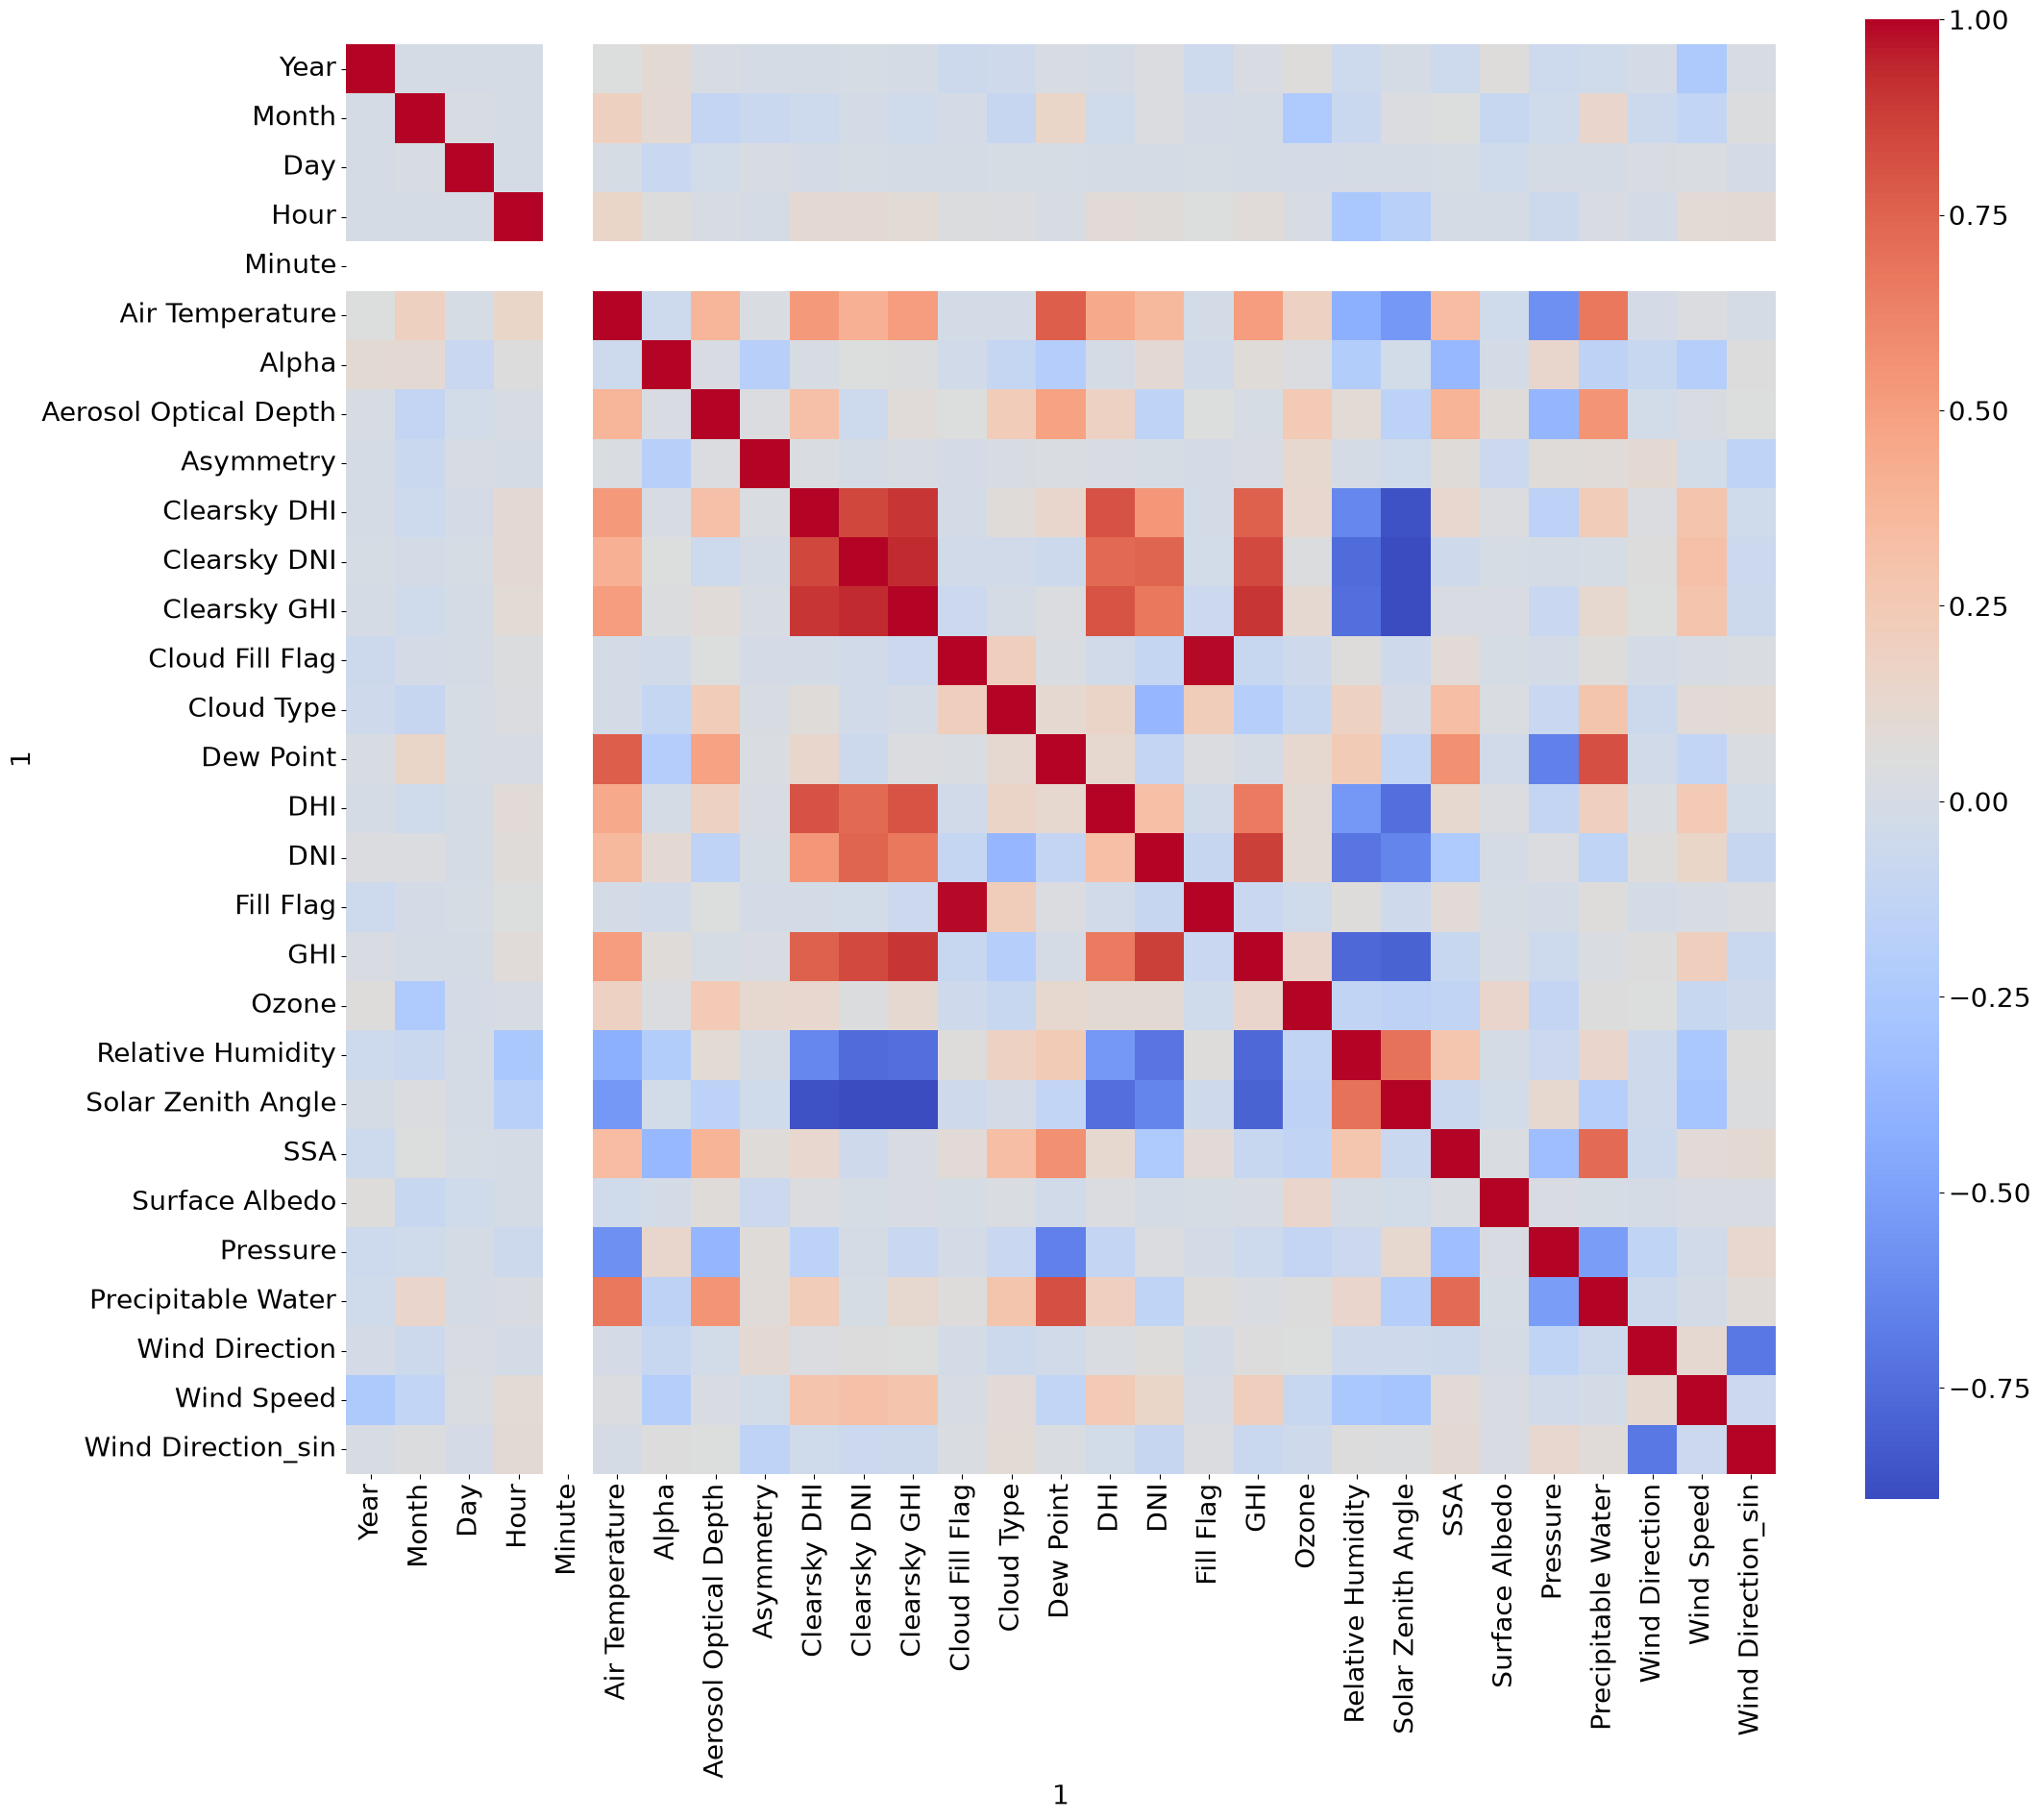

In [75]:
fig, ax = plt.subplots(figsize=(24,20))
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols[:]
#num_cols = num_cols.append(merged.columns[-1:])
corr = df[num_cols].corr(numeric_only=True)
plt.rcParams['font.size'] = 20
sns.heatmap(corr, annot=False, cmap="coolwarm",ax=ax)
ax.set_aspect(1)